# BIKE RENTAL REGRESSION

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler



**EDA**

In [ ]:
df=pd.read_csv('/content/Dataset.csv')

In [ ]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2011,springer,2011,1,0,No,6,No work,Clear,0.24,0.2879,0.81,0,3,13,16
1,2,01-01-2011,springer,2011,1,1,No,6,No work,Clear,0.22,0.2727,0.8,0,8,32,40
2,3,01-01-2011,springer,2011,1,2,No,6,No work,Clear,0.22,0.2727,?,0,5,27,32
3,4,01-01-2011,springer,2011,1,3,No,6,No work,Clear,0.24,0.2879,0.75,0,3,10,13
4,5,01-01-2011,springer,2011,1,4,No,6,No work,Clear,0.24,0.2879,0.75,0,0,1,1


In [ ]:
df.shape

(17379, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   instant     17379 non-null  int64 
 1   dteday      17379 non-null  object
 2   season      17379 non-null  object
 3   yr          17379 non-null  object
 4   mnth        17379 non-null  object
 5   hr          17379 non-null  int64 
 6   holiday     17379 non-null  object
 7   weekday     17379 non-null  int64 
 8   workingday  17379 non-null  object
 9   weathersit  17379 non-null  object
 10  temp        17379 non-null  object
 11  atemp       17379 non-null  object
 12  hum         17379 non-null  object
 13  windspeed   17379 non-null  object
 14  casual      17379 non-null  object
 15  registered  17379 non-null  object
 16  cnt         17379 non-null  int64 
dtypes: int64(4), object(13)
memory usage: 2.3+ MB


In [ ]:
df.describe()

,instant,hr,weekday,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000
mean,8690.0000,11.546752,3.003683,189.463088
std,5017.0295,6.914405,2.005771,181.387599
min,1.0000,0.000000,0.000000,1.000000
25%,4345.5000,6.000000,1.000000,40.000000
50%,8690.0000,12.000000,3.000000,142.000000
75%,13034.5000,18.000000,5.000000,281.000000
max,17379.0000,23.000000,6.000000,977.000000


In [ ]:
#Replacing '?' with NaN
for col in df.columns:
    if df[col].dtype == 'object':
        if '?' in df[col].unique():
            df[col] = df[col].replace('?', np.nan)

In [ ]:
# fix the springer typo
df['season'] = df['season'].replace('springer', 'spring')
print("Replaced 'springer' with 'spring' in the 'season' column.")

Replaced 'springer' with 'spring' in the 'season' column.


In [ ]:
# Convert columns to numeric, coercing errors to NaN
for col in ['yr','mnth','temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
# convert dteday to datetime
df['dteday'] = pd.to_datetime(df['dteday'], format='%d-%m-%Y')


In [ ]:
#checking data types after conversion
print("Data types after conversion:")
df.info()

Data types after conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17373 non-null  object        
 3   yr          17378 non-null  float64       
 4   mnth        17378 non-null  float64       
 5   hr          17379 non-null  int64         
 6   holiday     17378 non-null  object        
 7   weekday     17379 non-null  int64         
 8   workingday  17374 non-null  object        
 9   weathersit  17375 non-null  object        
 10  temp        17368 non-null  float64       
 11  atemp       17373 non-null  float64       
 12  hum         17373 non-null  float64       
 13  windspeed   17374 non-null  float64       
 14  casual      17378 non-null  float64       
 15  registered  17378 non-null  float64      

In [ ]:
#checking missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
instant        0
dteday         0
season         6
yr             1
mnth           1
hr             0
holiday        1
weekday        0
workingday     5
weathersit     4
temp          11
atemp          6
hum            6
windspeed      5
casual         1
registered     1
cnt            0
dtype: int64


In [ ]:
#Fill yr,mnth missing val from dteday
df['yr'] = df['yr'].fillna(df['dteday'].dt.year)
df['mnth'] = df['mnth'].fillna(df['dteday'].dt.month)

# Fill remaining  missing numerical values with the median
numerical_cols_with_missing = df.select_dtypes(include=['number']).columns[
    df.select_dtypes(include=['number']).isnull().any()]

for col in numerical_cols_with_missing:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with the mode
categorical_cols_with_missing = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').isnull().any()]

for col in categorical_cols_with_missing:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

In [ ]:
# Verify that all missing values have been handled
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
#checking the duplicates
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows in the DataFrame: {duplicate_rows}")

Number of duplicate rows in the DataFrame: 0


In [ ]:
#checking the unique values
for column in df.columns:
    print(f"Count of unique values for column '{column}': {df[column].nunique()}")

Count of unique values for column 'instant': 17379
Count of unique values for column 'dteday': 731
Count of unique values for column 'season': 4
Count of unique values for column 'yr': 2
Count of unique values for column 'mnth': 12
Count of unique values for column 'hr': 24
Count of unique values for column 'holiday': 2
Count of unique values for column 'weekday': 7
Count of unique values for column 'workingday': 2
Count of unique values for column 'weathersit': 4
Count of unique values for column 'temp': 50
Count of unique values for column 'atemp': 65
Count of unique values for column 'hum': 89
Count of unique values for column 'windspeed': 30
Count of unique values for column 'casual': 322
Count of unique values for column 'registered': 776
Count of unique values for column 'cnt': 869


In [ ]:
#converting to int
df['yr'] = df['yr'].astype(int)
df['mnth'] = df['mnth'].astype(int)
df['casual'] = df['casual'].astype(int)
df['registered'] = df['registered'].astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  object        
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  object        
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  object        
 9   weathersit  17379 non-null  object        
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Data visualization**

| feature    |   lower_bound |   upper_bound |   n_outliers |
|:-----------|--------------:|--------------:|-------------:|
| temp       |      -0.14    |       1.14    |            0 |
| atemp      |      -0.09855 |       1.05305 |            0 |
| hum        |       0.03    |       1.23    |           22 |
| windspeed  |      -0.1193  |       0.4775  |          341 |
| casual     |     -62       |     114       |         1192 |
| registered |    -245       |     499       |          680 |
| cnt        |    -321.5     |     642.5     |          505 |


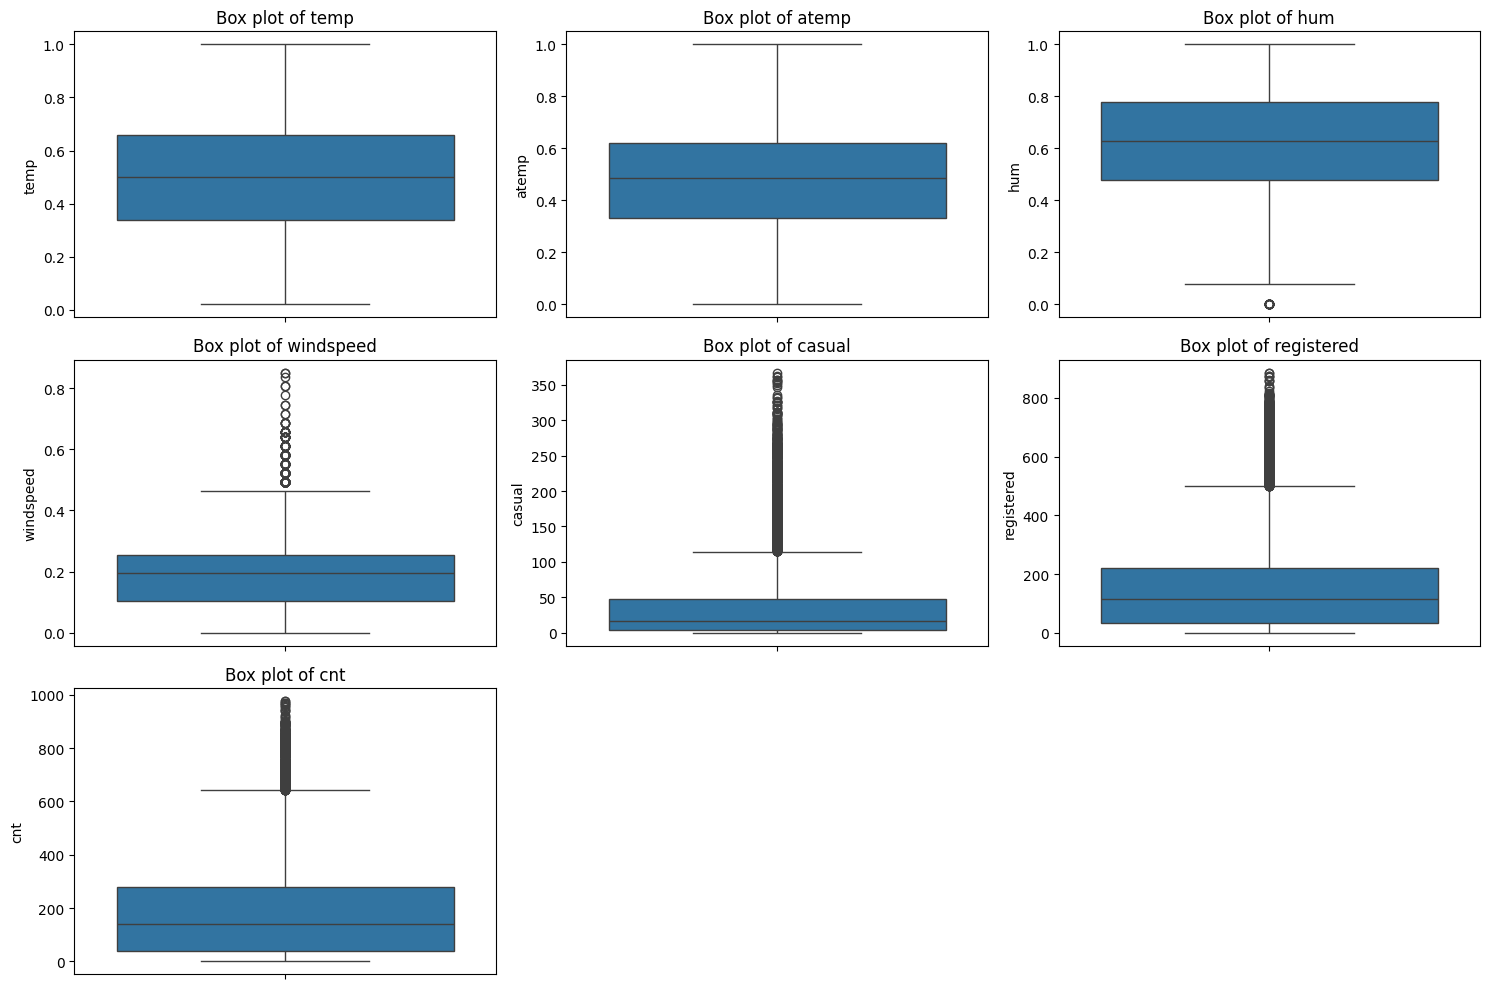

In [ ]:
#Outlier Detection using IQR Method
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, Q1, Q3, IQR, lower_bound, upper_bound

numerical_cols = ['temp', 'atemp', 'hum', 'windspeed','casual','registered','cnt']

outlier_summary_data = []
for col in numerical_cols:
    outliers, Q1, Q3, IQR, lower_bound, upper_bound = detect_outliers(df, col)
    n_outliers = len(outliers)
    outlier_summary_data.append({
        'feature': col,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': n_outliers
    })

outlier_summary_df = pd.DataFrame(outlier_summary_data)
print(outlier_summary_df.to_markdown(index=False))

#plot Boxplot
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

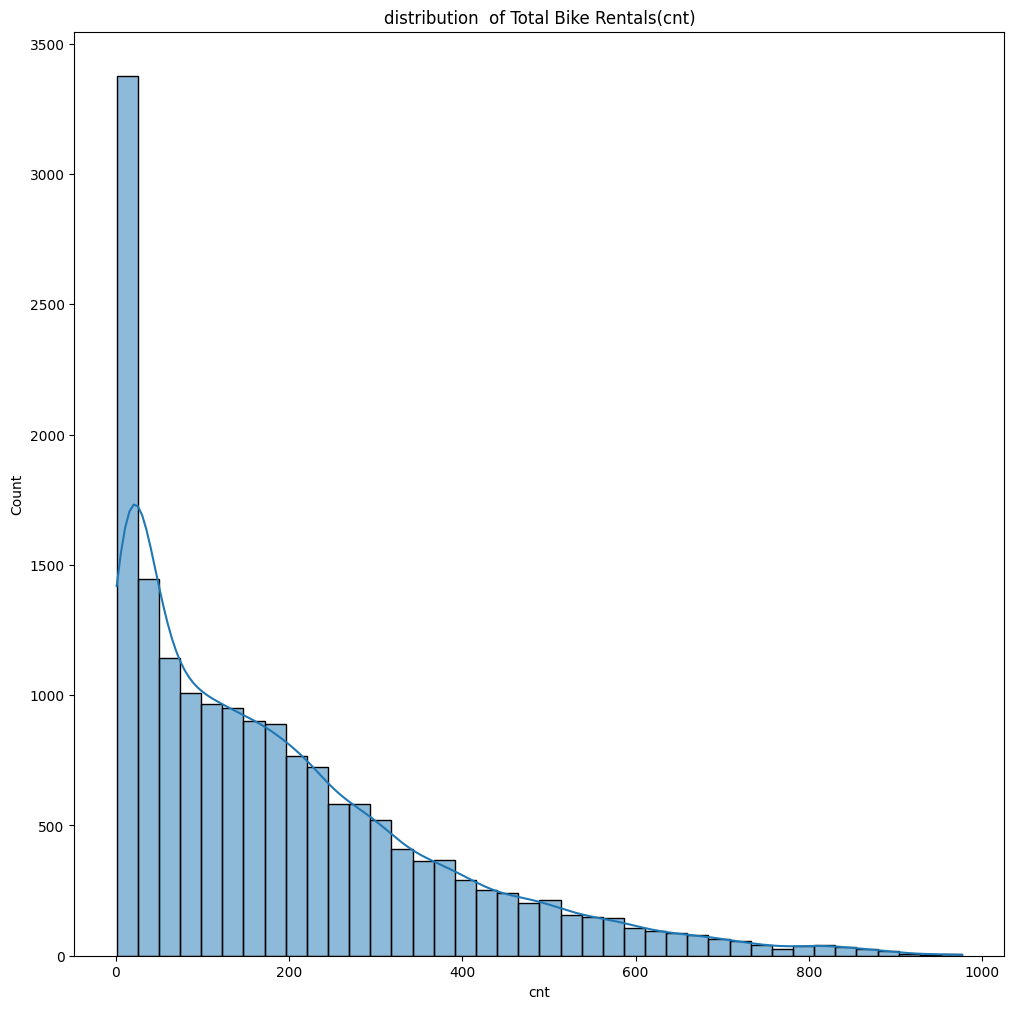

In [ ]:
#histograms
plt.figure(figsize=(12,12))
sns.histplot(df['cnt'],bins=40, kde=True)
plt.title('distribution  of Total Bike Rentals(cnt)')
plt.show()


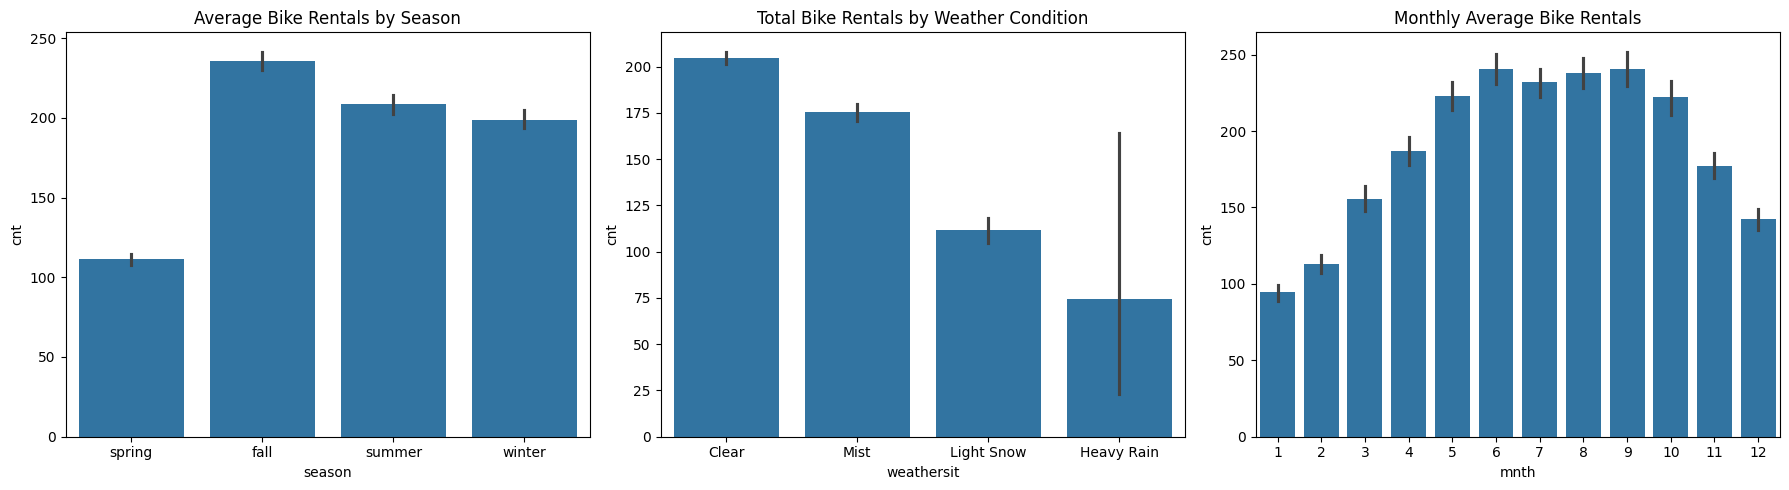

In [ ]:
#barcharts
fig,ax=plt.subplots( 1,3,figsize=(18,5))
sns.barplot(x='season', y='cnt', data=df,ax=ax[0])
ax[0].set_title('Average Bike Rentals by Season')
sns.barplot(x='weathersit', y='cnt', data=df,ax=ax[1])
ax[1].set_title('Total Bike Rentals by Weather Condition')
sns.barplot(x='mnth', y='cnt', data=df,ax=ax[2])
ax[2].set_title('Monthly Average Bike Rentals')
plt.tight_layout()
plt.show()





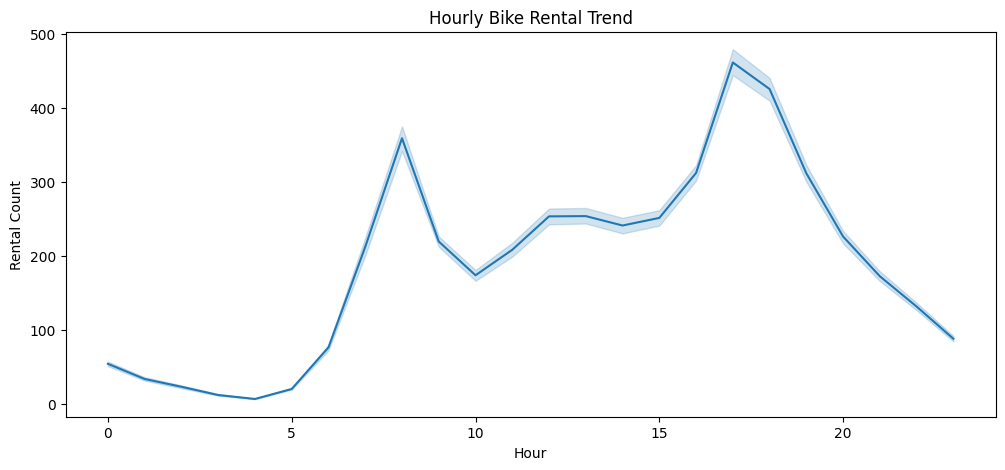

In [ ]:
plt.figure(figsize=(12,5))
sns.lineplot(x='hr', y='cnt', data=df)
plt.title("Hourly Bike Rental Trend")
plt.xlabel("Hour")
plt.ylabel("Rental Count")

plt.show()

Text(0.5, 1.0, 'Working Day vs Bike Rentals')

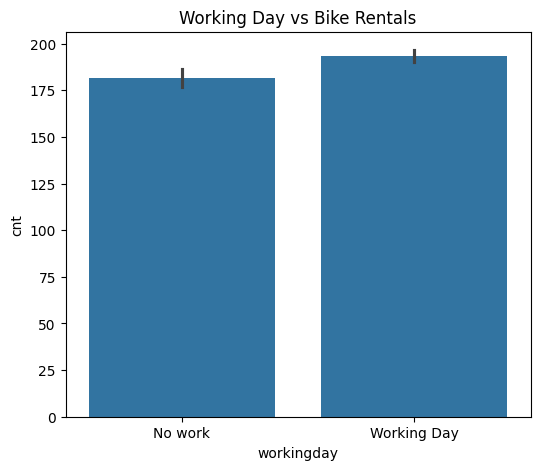

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x='workingday', y='cnt', data=df)
plt.title("Working Day vs Bike Rentals")

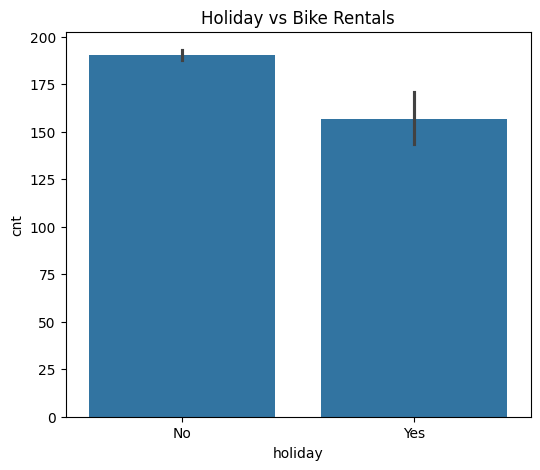

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x='holiday', y='cnt', data=df)
plt.title("Holiday vs Bike Rentals")

plt.show()

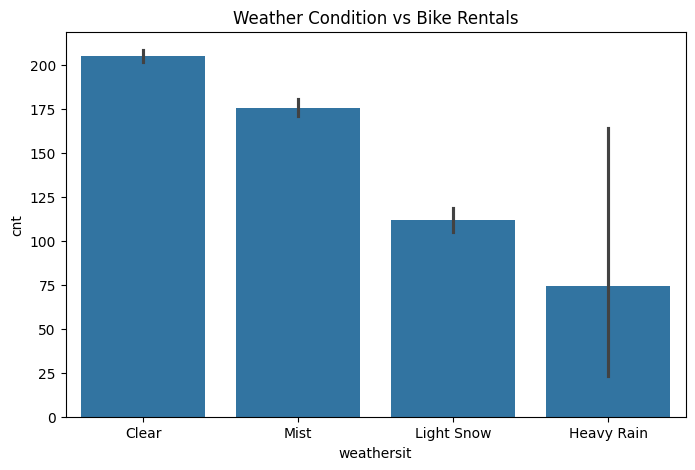

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='weathersit', y='cnt', data=df)
plt.title("Weather Condition vs Bike Rentals")

plt.show()

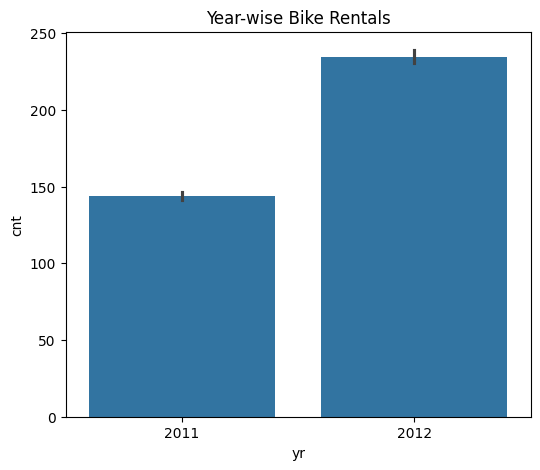

In [ ]:
plt.figure(figsize=(6,5))
sns.barplot(x='yr', y='cnt', data=df)
plt.title("Year-wise Bike Rentals")

plt.show()

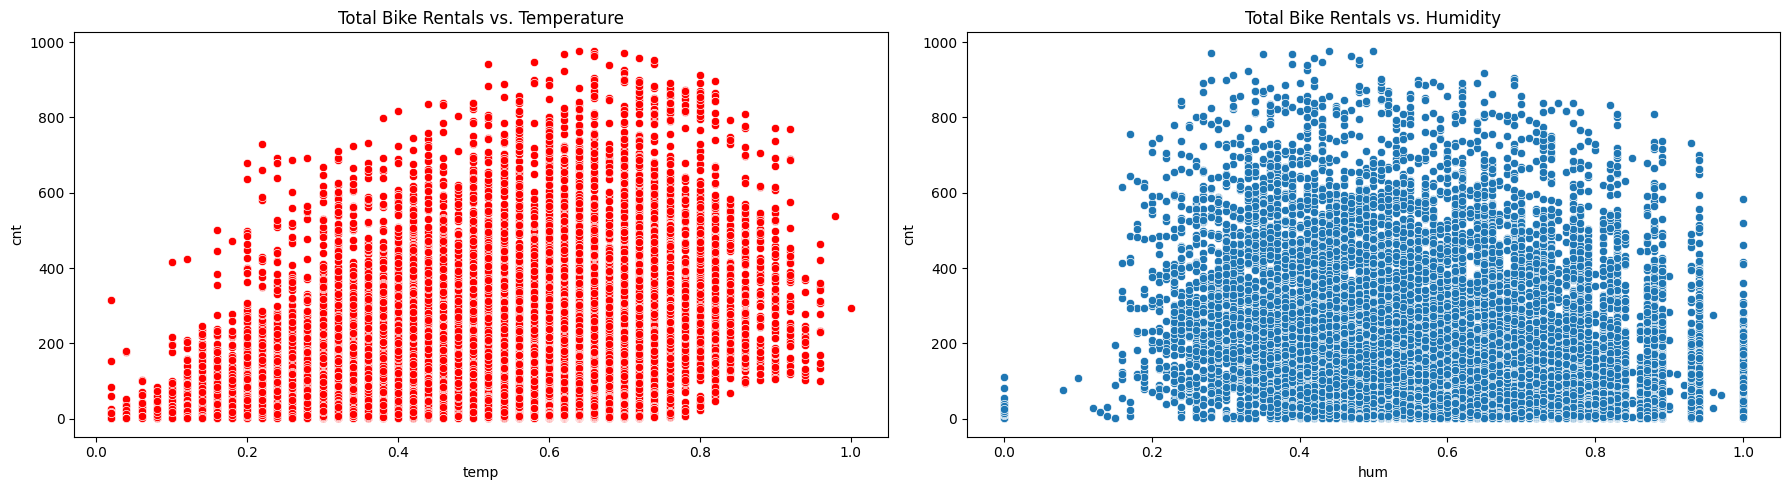

In [ ]:
#scatter plots
fig, ax = plt.subplots(1, 2, figsize=(18, 5))
sns.scatterplot(x='temp', y='cnt', data=df, ax=ax[0],color='red')
ax[0].set_title('Total Bike Rentals vs. Temperature')
sns.scatterplot(x='hum', y='cnt', data=df, ax=ax[1])
ax[1].set_title('Total Bike Rentals vs. Humidity')
plt.tight_layout()
plt.show()

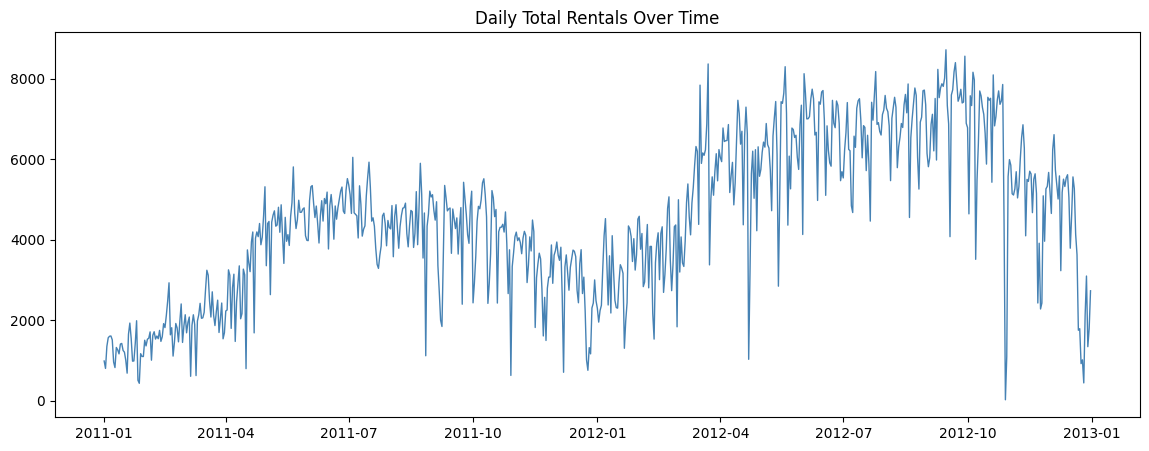

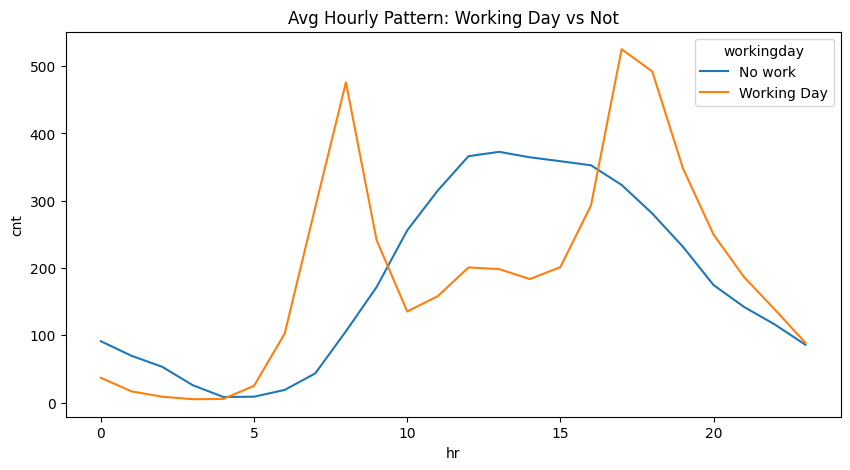

In [ ]:
#timeseries
daily = df.groupby('dteday')['cnt'].sum().reset_index()
plt.figure(figsize=(14,5))
plt.plot(daily['dteday'], daily['cnt'], color='steelblue', linewidth=1)
plt.title("Daily Total Rentals Over Time")
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(x='hr', y='cnt', data=df, hue='workingday', estimator=np.mean, errorbar=None)
plt.title("Avg Hourly Pattern: Working Day vs Not")
plt.show()

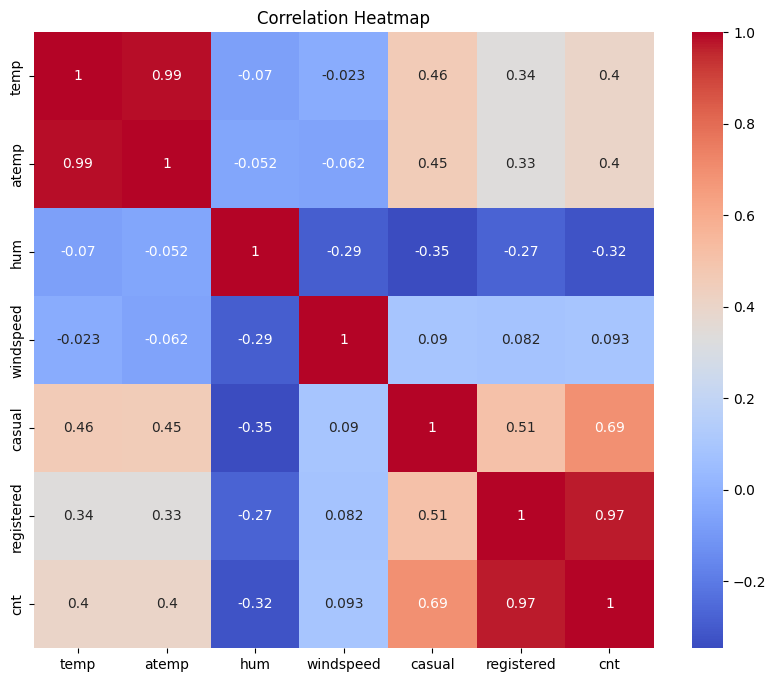

In [ ]:
# correleation heatmap
plt.figure(figsize=(10,8))
column=['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
sns.heatmap(df[column].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

**Feature Engineering**

In [ ]:
def peak_hour(hour):
    if hour in [7,8,9,17,18,19]:
        return 1
    else:
        return 0

df['Peak_Hour'] = df['hr'].apply(peak_hour)

df[['hr','Peak_Hour']].head(10)

,hr,Peak_Hour
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,1
8,8,1
9,9,1


In [ ]:
#Extarct features from hr
def hour_bucket(h):
    if h in [7,8,9]: return 'morning_rush'
    elif h in [17,18,19]: return 'evening_rush'
    elif 10 <= h <= 16: return 'daytime'
    else: return 'night'

df['hour_bucket'] = df['hr'].apply(hour_bucket)

In [ ]:
#Weekend feature
df['Weekend'] = df['weekday'].apply(lambda x: 1 if x in [0,6] else 0)

df[['weekday','Weekend']].head()

,weekday,Weekend
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1


In [ ]:
#Temp Difference
df['Temp_Difference'] = abs(df['temp'] - df['atemp'])

In [ ]:
month_map = {
1:'Jan',2:'Feb',3:'Mar',4:'Apr',
5:'May',6:'Jun',7:'Jul',8:'Aug',
9:'Sep',10:'Oct',11:'Nov',12:'Dec'
}

df['Month'] = df['mnth'].map(month_map)

df[['mnth','Month']].head()

,mnth,Month
0,1,Jan
1,1,Jan
2,1,Jan
3,1,Jan
4,1,Jan


In [ ]:
# One-Hot Encode 'season', weathersit' and 'hour_bucket
df = pd.get_dummies(df, columns=['season', 'weathersit'], drop_first=True)



In [ ]:
#Label Encode 'holiday' ,'hour_bucket' and 'workingday'
label_encoder = LabelEncoder()
df['holiday'] = label_encoder.fit_transform(df['holiday'])
df['workingday'] = label_encoder.fit_transform(df['workingday'])
df['hour_bucket'] = label_encoder.fit_transform(df['hour_bucket'])

In [ ]:
#converting to int
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   instant                17379 non-null  int64         
 1   dteday                 17379 non-null  datetime64[ns]
 2   yr                     17379 non-null  int64         
 3   mnth                   17379 non-null  int64         
 4   hr                     17379 non-null  int64         
 5   holiday                17379 non-null  int64         
 6   weekday                17379 non-null  int64         
 7   workingday             17379 non-null  int64         
 8   temp                   17379 non-null  float64       
 9   atemp                  17379 non-null  float64       
 10  hum                    17379 non-null  float64       
 11  windspeed              17379 non-null  float64       
 12  casual                 17379 non-null  int64         
 13  r

In [ ]:
# Removing unnecessary columns
df = df.drop(columns=['instant','dteday','Month', 'casual', 'registered'])

In [ ]:
#Scaling
scaler = StandardScaler()
df[['temp', 'atemp', 'hum', 'windspeed']] = scaler.fit_transform(df[['temp', 'atemp', 'hum', 'windspeed']])

In [ ]:
print("Updated DataFrame")
display(df.head())


Updated DataFrame


,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,...,Peak_Hour,hour_bucket,Weekend,Temp_Difference,season_spring,season_summer,season_winter,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist
0,2011,1,0,0,6,0,-1.336047,-1.094064,0.947596,-1.554228,...,0,3,1,0.0479,1,0,0,0,0,0
1,2011,1,1,0,6,0,-1.439966,-1.182542,0.895755,-1.554228,...,0,3,1,0.0527,1,0,0,0,0,0
2,2011,1,2,0,6,0,-1.439966,-1.182542,0.014470,-1.554228,...,0,3,1,0.0527,1,0,0,0,0,0
3,2011,1,3,0,6,0,-1.336047,-1.094064,0.636554,-1.554228,...,0,3,1,0.0479,1,0,0,0,0,0
4,2011,1,4,0,6,0,-1.336047,-1.094064,0.636554,-1.554228,...,0,3,1,0.0479,1,0,0,0,0,0


In [ ]:
print("Updated Dataypes:")
df.info()

Updated Dataypes:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   yr                     17379 non-null  int64  
 1   mnth                   17379 non-null  int64  
 2   hr                     17379 non-null  int64  
 3   holiday                17379 non-null  int64  
 4   weekday                17379 non-null  int64  
 5   workingday             17379 non-null  int64  
 6   temp                   17379 non-null  float64
 7   atemp                  17379 non-null  float64
 8   hum                    17379 non-null  float64
 9   windspeed              17379 non-null  float64
 10  cnt                    17379 non-null  int64  
 11  Peak_Hour              17379 non-null  int64  
 12  hour_bucket            17379 non-null  int64  
 13  Weekend                17379 non-null  int64  
 14  Temp_Difference        17379 non-nul

In [ ]:
print("final Shape:")
df.shape

final Shape:


(17379, 21)

In [ ]:
df.to_csv('bike_rental_preprocessed_data.csv', index=False)
print("DataFrame saved to 'bike_rental_preprocessed_data.csv'")

DataFrame saved to 'bike_rental_preprocessed_data.csv'


**Model Building**

In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('cnt', axis=1)
y = df['cnt']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (13903, 20)
X_test shape: (3476, 20)
y_train shape: (13903,)
y_test shape: (3476,)


### **Linear Regression Model**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Initialize and train the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_lr:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lr:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_lr:.2f}")
print(f"  R-squared (R2): {r2_lr:.2f}")

Linear Regression Model Performance:
  Mean Squared Error (MSE): 11738.37
  Root Mean Squared Error (RMSE): 108.34
  Mean Absolute Error (MAE): 82.04
  R-squared (R2): 0.63


### **Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree Regressor model
decision_tree_model = DecisionTreeRegressor(random_state=42)
decision_tree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the model
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree Regressor Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_dt:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_dt:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_dt:.2f}")
print(f"  R-squared (R2): {r2_dt:.2f}")

Decision Tree Regressor Model Performance:
  Mean Squared Error (MSE): 3288.75
  Root Mean Squared Error (RMSE): 57.35
  Mean Absolute Error (MAE): 33.64
  R-squared (R2): 0.90


### **Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest Regressor model
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Model Performance:
  Mean Squared Error (MSE): 1742.85
  Root Mean Squared Error (RMSE): 41.75
  Mean Absolute Error (MAE): 24.61
  R-squared (R2): 0.94


### **Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting Regressor model
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_gb = gradient_boosting_model.predict(X_test)

# Evaluate the model
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print(f"Gradient Boosting Regressor Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_gb:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_gb:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_gb:.2f}")
print(f"  R-squared (R2): {r2_gb:.2f}")

Gradient Boosting Regressor Model Performance:
  Mean Squared Error (MSE): 3786.12
  Root Mean Squared Error (RMSE): 61.53
  Mean Absolute Error (MAE): 42.78
  R-squared (R2): 0.88


### **Extreme Gradient Boosting (XGBoost) Regressor**

In [ ]:
import xgboost as xgb

# Initialize and train the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Regressor Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_xgb:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"  R-squared (R2): {r2_xgb:.2f}")

XGBoost Regressor Model Performance:
  Mean Squared Error (MSE): 1581.66
  Root Mean Squared Error (RMSE): 39.77
  Mean Absolute Error (MAE): 24.78
  R-squared (R2): 0.95


### **Hyperparameter Tuning for XGBoost Regressor**

In [ ]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],  # Number of boosting rounds
    'max_depth': [3, 5, 7],           # Maximum depth of a tree
    'learning_rate': [0.05, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.8, 0.9],     # Subsample ratio of the training instance
    'colsample_bytree': [0.7, 0.8, 0.9] # Subsample ratio of columns when constructing each tree
}

# Initialize GridSearchCV for XGBoost
grid_search_xgb = GridSearchCV(estimator=xgb.XGBRegressor(random_state=42, eval_metric='rmse'),
                              param_grid=param_grid_xgb, cv=3, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search_xgb.fit(X_train, y_train)

# Get the best parameters and best score
best_params_xgb = grid_search_xgb.best_params_
best_score_xgb = grid_search_xgb.best_score_

print(f"Best parameters for XGBoost: {best_params_xgb}")
print(f"Best R-squared score (from GridSearchCV): {best_score_xgb:.2f}")

# Train the XGBoost model with the best parameters
best_xgb_model = xgb.XGBRegressor(**best_params_xgb, random_state=42, eval_metric='rmse')
best_xgb_model.fit(X_train, y_train)

# Make predictions on the test set with the best model
y_pred_best_xgb = best_xgb_model.predict(X_test)

# Evaluate the best model
mse_best_xgb = mean_squared_error(y_test, y_pred_best_xgb)
rmse_best_xgb = np.sqrt(mse_best_xgb)
mae_best_xgb = mean_absolute_error(y_test, y_pred_best_xgb)
r2_best_xgb = r2_score(y_test, y_pred_best_xgb)

print(f"\nOptimized XGBoost Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_best_xgb:.2f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_best_xgb:.2f}")
print(f"  Mean Absolute Error (MAE): {mae_best_xgb:.2f}")
print(f"  R-squared (R2): {r2_best_xgb:.2f}")

Fitting 3 folds for each of 243 candidates, totalling 729 fits
Best parameters for XGBoost: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best R-squared score (from GridSearchCV): 0.95

Optimized XGBoost Model Performance:
  Mean Squared Error (MSE): 1393.79
  Root Mean Squared Error (RMSE): 37.33
  Mean Absolute Error (MAE): 22.62
  R-squared (R2): 0.96


### **Feature Importance of Optimized XGBoost Regressor**

Top 10 Feature Importances for Optimized XGBoost:


,feature,importance
11,hour_bucket,0.302509
10,Peak_Hour,0.133111
5,workingday,0.117996
0,yr,0.079771
2,hr,0.073779
12,Weekend,0.067853
14,season_spring,0.055109
7,atemp,0.043003
18,weathersit_Light Snow,0.032180
6,temp,0.027571


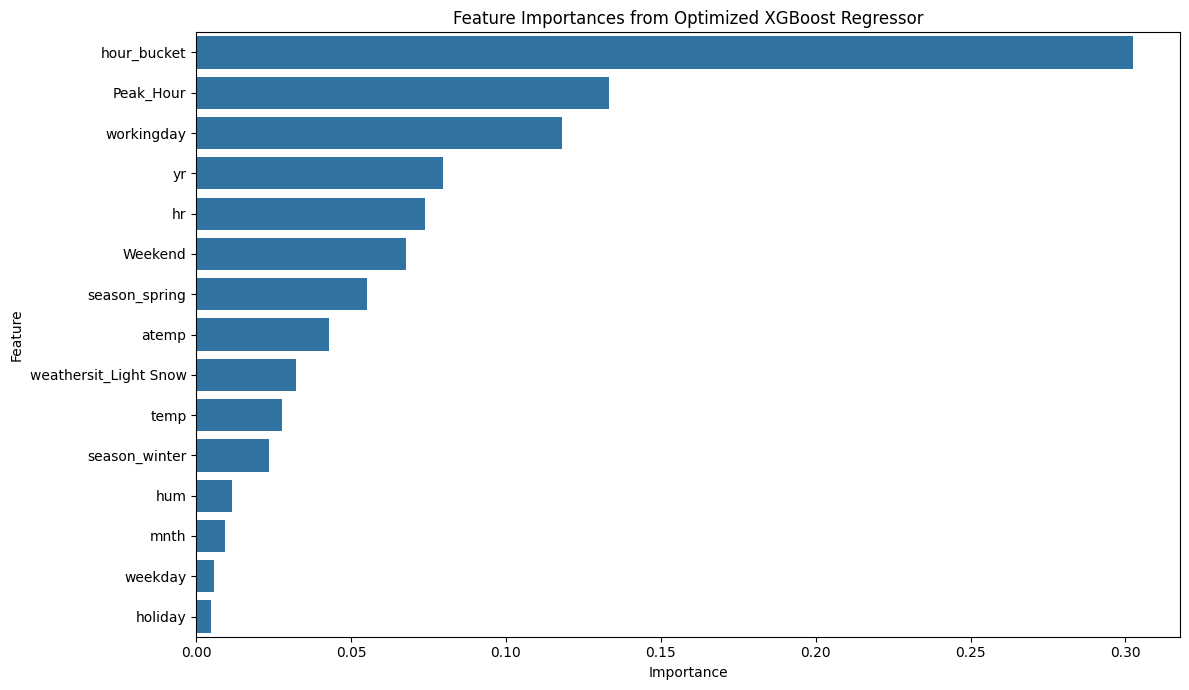

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best XGBoost model
feature_importances_xgb = best_xgb_model.feature_importances_

# Get feature names from X_train
feature_names_xgb = X_train.columns

# Create a DataFrame for better visualization
importance_df_xgb = pd.DataFrame({'feature': feature_names_xgb, 'importance': feature_importances_xgb})

# Sort the DataFrame by importance in descending order
importance_df_xgb = importance_df_xgb.sort_values(by='importance', ascending=False)

print("Top 10 Feature Importances for Optimized XGBoost:")
display(importance_df_xgb.head(10))

# Plotting feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=importance_df_xgb.head(15))
plt.title('Feature Importances from Optimized XGBoost Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### **Save the Optimized XGBoost Model**

In [ ]:
best_xgb_model.save_model("optimized_xgboost_model.json")

### **Compare Actual vs. Predicted Values**

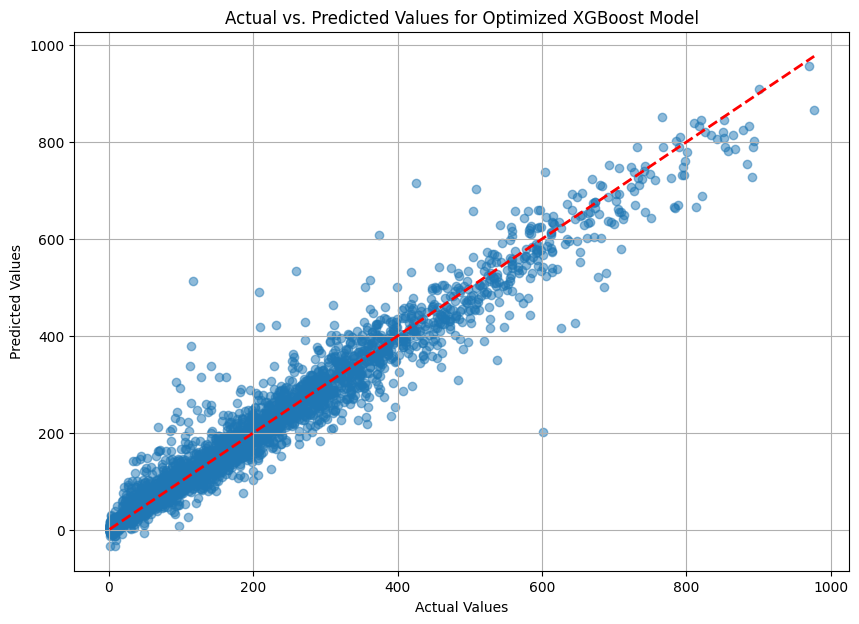

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(y_test, y_pred_best_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values for Optimized XGBoost Model')
plt.grid(True)
plt.show()

### **Analyze Model Residuals**

Residuals Summary Statistics:


,cnt
count,3476.000000
mean,-0.552803
std,37.334738
min,-396.683472
25%,-13.440884
50%,-0.627178
75%,12.205361
max,399.353882


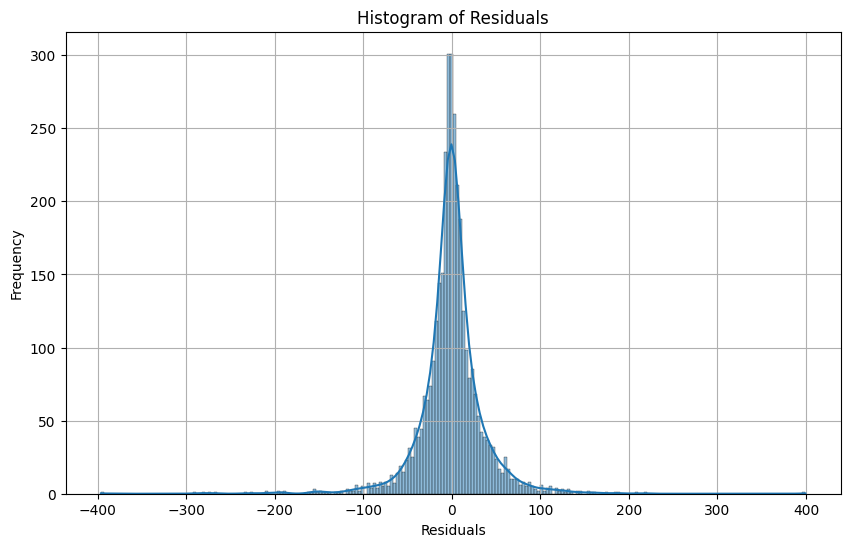

In [ ]:
# Calculate residuals
residuals = y_test - y_pred_best_xgb

# Print summary statistics of residuals
print("Residuals Summary Statistics:")
display(residuals.describe())

# Plot histogram of residuals to check for normal distribution
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### **Deployment Application File**

In [ ]:
from google.colab import files
files.download("optimized_xgboost_model.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor

# Load the optimized XGBoost model
loaded_model = XGBRegressor()
loaded_model.load_model("optimized_xgboost_model.json")

print(f"Model '{"optimized_xgboost_model.json"}' loaded successfully.")

def predict_bike_rentals(input_data: pd.DataFrame):
    """
    Makes predictions using the loaded XGBoost model.

    Args:
        input_data (pd.DataFrame): A DataFrame containing the features for prediction.
                                   The columns must match the training data features.

    Returns:
        np.ndarray: Predicted bike rental counts.
    """
    predictions = loaded_model.predict(input_data)
    return predictions

# Example Usage (assuming you have new data in the same format as X_test)
# For demonstration, we will use a slice of X_test.
# In a real deployment, this `new_data_for_prediction` would come from an external source.

# Ensure the columns match the order and names used during training
# For simplicity, we'll use a sample from X_test, which already has the correct format.
example_new_data = X_test.head(5)

print("\nExample new data for prediction:")
display(example_new_data)

# Make predictions
example_predictions = predict_bike_rentals(example_new_data)

print("\nPredictions for example data:")
for i, pred in enumerate(example_predictions):
    print(f"Input {i+1}: Predicted rentals = {pred:.2f}")


Model 'optimized_xgboost_model.json' loaded successfully.

Example new data for prediction:


,yr,mnth,hr,holiday,weekday,workingday,temp,atemp,hum,windspeed,Peak_Hour,hour_bucket,Weekend,Temp_Difference,season_spring,season_summer,season_winter,weathersit_Heavy Rain,weathersit_Light Snow,weathersit_Mist
12830,2012,6,19,0,6,0,1.573674,1.287267,-1.851781,0.032042,1,1,1,0.1030,0,0,0,0,0,0
8688,2012,1,20,1,1,0,-1.336047,-1.446811,-1.126017,0.276524,0,3,0,0.0127,1,0,0,0,0,0
7091,2011,10,2,0,5,1,-0.920372,-1.006169,0.169991,0.764670,0,3,0,0.0170,0,0,1,0,0,0
12230,2012,5,19,0,2,1,1.469756,1.375163,-0.555773,1.374648,1,1,0,0.0679,0,1,0,0,0,0
431,2011,1,0,0,4,1,-1.232128,-1.446811,-0.348412,1.619130,0,3,0,0.0327,1,0,0,0,0,0



Predictions for example data:
Input 1: Predicted rentals = 400.42
Input 2: Predicted rentals = 104.69
Input 3: Predicted rentals = 3.57
Input 4: Predicted rentals = 555.64
Input 5: Predicted rentals = 17.97


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import pandas as pd
import numpy as np

# --- Re-load the original dataset to accurately recreate the scaler and label encoder ---
# This is necessary because the `df` in the current kernel state has already been transformed.
# We need the `df` state *before* scaling and *before* label encoding for fitting the preprocessors.
df_raw_for_preprocessors = pd.read_csv('/content/Dataset.csv')

# --- Repeat initial cleaning/feature engineering steps for preprocessor fitting ---
# Replace '?' with NaN
for col in df_raw_for_preprocessors.columns:
    if df_raw_for_preprocessors[col].dtype == 'object':
        if '?' in df_raw_for_preprocessors[col].unique():
            df_raw_for_preprocessors[col] = df_raw_for_preprocessors[col].replace('?', np.nan)

# Fix the 'springer' typo
df_raw_for_preprocessors['season'] = df_raw_for_preprocessors['season'].replace('springer', 'spring')

# Convert columns to numeric, coercing errors to NaN
for col in ['yr','mnth','temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']:
    if col in df_raw_for_preprocessors.columns:
        df_raw_for_preprocessors[col] = pd.to_numeric(df_raw_for_preprocessors[col], errors='coerce')

# Convert dteday to datetime
df_raw_for_preprocessors['dteday'] = pd.to_datetime(df_raw_for_preprocessors['dteday'], format='%d-%m-%Y')

# Fill yr,mnth missing val from dteday
df_raw_for_preprocessors['yr'] = df_raw_for_preprocessors['yr'].fillna(df_raw_for_preprocessors['dteday'].dt.year)
df_raw_for_preprocessors['mnth'] = df_raw_for_preprocessors['mnth'].fillna(df_raw_for_preprocessors['dteday'].dt.month)

# Fill remaining numerical missing values with the median
numerical_cols_with_missing = df_raw_for_preprocessors.select_dtypes(include=['number']).columns[
    df_raw_for_preprocessors.select_dtypes(include=['number']).isnull().any()]
for col in numerical_cols_with_missing:
    df_raw_for_preprocessors[col] = df_raw_for_preprocessors[col].fillna(df_raw_for_preprocessors[col].median())

# Fill missing categorical values with the mode
categorical_cols_with_missing = df_raw_for_preprocessors.select_dtypes(include='object').columns[
    df_raw_for_preprocessors.select_dtypes(include='object').isnull().any()]
for col in categorical_cols_with_missing:
    if not df_raw_for_preprocessors[col].mode().empty:
        df_raw_for_preprocessors[col] = df_raw_for_preprocessors[col].fillna(df_raw_for_preprocessors[col].mode().iloc[0])

# Convert to int
df_raw_for_preprocessors['yr'] = df_raw_for_preprocessors['yr'].astype(int)
df_raw_for_preprocessors['mnth'] = df_raw_for_preprocessors['mnth'].astype(int)
df_raw_for_preprocessors['casual'] = df_raw_for_preprocessors['casual'].astype(int)
df_raw_for_preprocessors['registered'] = df_raw_for_preprocessors['registered'].astype(int)

# Define hour_bucket function (to get string labels for LabelEncoder)
def hour_bucket_str_func(h):
    if h in [7,8,9]: return 'morning_rush'
    elif h in [17,18,19]: return 'evening_rush'
    elif 10 <= h <= 16: return 'daytime'
    else: return 'night'

df_raw_for_preprocessors['hour_bucket_str'] = df_raw_for_preprocessors['hr'].apply(hour_bucket_str_func)

# --- Fit and Save StandardScaler ---
# The scaler was fitted on these four columns *before* they were themselves transformed
scaler = StandardScaler()
scaler.fit(df_raw_for_preprocessors[['temp', 'atemp', 'hum', 'windspeed']])
joblib.dump(scaler, 'scaler.pkl')
print("StandardScaler saved to scaler.pkl")

# --- Fit and Save LabelEncoder for hour_bucket ---
hour_bucket_encoder = LabelEncoder()
hour_bucket_encoder.fit(df_raw_for_preprocessors['hour_bucket_str'])
joblib.dump(hour_bucket_encoder, 'hour_bucket_encoder.pkl')
print("LabelEncoder for hour_bucket saved to hour_bucket_encoder.pkl")

StandardScaler saved to scaler.pkl
LabelEncoder for hour_bucket saved to hour_bucket_encoder.pkl


---

### **Step 2: Create the Streamlit Application (`app.py`)**

Now, here's the code for your Streamlit application. Copy this entire code block and save it as a Python file named `app.py` in the same directory where your `optimized_xgboost_model.pkl`, `scaler.pkl`, and `hour_bucket_encoder.pkl` files are located.


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import numpy as np
import xgboost as xgb # Import xgboost for loading the model

# --- Load the trained model and preprocessors ---
try:
    # Load the XGBRegressor model from JSON
    loaded_model = xgb.XGBRegressor()
    loaded_model.load_model("optimized_xgboost_model.json")

    scaler = joblib.load("scaler.pkl")
    hour_bucket_encoder = joblib.load("hour_bucket_encoder.pkl")

except Exception as e:
    st.error(f"Error loading model or preprocessors:\n{e}")
    st.stop()

# --- Feature Engineering Functions (must match preprocessing pipeline) ---
def get_peak_hour(hour):
    if hour in [7, 8, 9, 17, 18, 19]:
        return 1
    else:
        return 0

def get_hour_bucket_str(h):
    if h in [7, 8, 9]: return 'morning_rush'
    elif h in [17, 18, 19]: return 'evening_rush'
    elif 10 <= h <= 16: return 'daytime'
    else: return 'night'

def get_weekend(weekday):
    # 0=Sunday, 6=Saturday
    return 1 if weekday in [0, 6] else 0

# --- Streamlit App ---
st.title('🚴 Bike Rental Demand Prediction')
st.write("Predict the hourly bike rental demand based on various environmental and time-based factors.")

# --- User Inputs (Sidebar) ---
st.sidebar.header('Input Features')

# Time-based features
yr = st.sidebar.selectbox('Year', [2011, 2012], help='The year of the prediction.')
mnth = st.sidebar.slider('Month', 1, 12, 7, help='The month of the prediction (1=Jan, 12=Dec).')
hr = st.sidebar.slider('Hour', 0, 23, 12, help='The hour of the day (0-23).')
weekday = st.sidebar.slider('Day of Week (0=Sun, 6=Sat)', 0, 6, 3, help='The day of the week.')
holiday_str = st.sidebar.selectbox('Holiday', ['No', 'Yes'], help='Is it a holiday?')
workingday_str = st.sidebar.selectbox('Working Day', ['No work', 'Working Day'], help='Is it a working day?')

# Weather-related features (raw inputs)
temp_raw = st.sidebar.slider('Temperature (Normalized 0-1)', 0.0, 1.0, 0.5, 0.01, help='Normalized temperature (0-1).')
atemp_raw = st.sidebar.slider('Feeling Temperature (Normalized 0-1)', 0.0, 1.0, 0.5, 0.01, help='Normalized feeling temperature (0-1).')
hum_raw = st.sidebar.slider('Humidity (Normalized 0-1)', 0.0, 1.0, 0.5, 0.01, help='Normalized humidity (0-1).')
windspeed_raw = st.sidebar.slider('Windspeed (Normalized 0-1)', 0.0, 1.0, 0.2, 0.01, help='Normalized windspeed (0-1).')

# Categorical features for one-hot encoding
season_str = st.sidebar.selectbox('Season', ['spring', 'summer', 'fall', 'winter'], help='The season of the year.')
weathersit_str = st.sidebar.selectbox('Weather Situation', ['Clear', 'Mist', 'Light Snow', 'Heavy Rain'], help='The general weather conditions.')

# --- Prepare Input Data for Prediction ---
if st.sidebar.button('Predict Demand'):
    # Convert string inputs to numerical
    holiday = 1 if holiday_str == 'Yes' else 0
    # The original 'workingday' column was 'No work' or 'Working Day', and 'No work' was encoded as 0, 'Working Day' as 1.
    workingday = 1 if workingday_str == 'Working Day' else 0

    # Apply scaling to temp, atemp, hum, windspeed using the loaded scaler
    # Note: scaler expects a 2D array, even for a single sample
    scaled_features_array = scaler.transform(np.array([[temp_raw, atemp_raw, hum_raw, windspeed_raw]]))
    temp, atemp, hum, windspeed = scaled_features_array[0]

    # Derived features
    peak_hour = get_peak_hour(hr)
    hour_bucket_encoded = hour_bucket_encoder.transform([get_hour_bucket_str(hr)])[0]
    weekend = get_weekend(weekday)
    # Temp_Difference was calculated from RAW temp/atemp in preprocessing
    temp_difference = abs(temp_raw - atemp_raw)

    # One-hot encode season and weathersit
    season_spring = 1 if season_str == 'spring' else 0
    season_summer = 1 if season_str == 'summer' else 0
    season_winter = 1 if season_str == 'winter' else 0

    weathersit_heavy_rain = 1 if weathersit_str == 'Heavy Rain' else 0
    weathersit_light_snow = 1 if weathersit_str == 'Light Snow' else 0
    weathersit_mist = 1 if weathersit_str == 'Mist' else 0

    # Create a DataFrame for prediction, ensuring column order matches X_train.columns
    # The columns from X_train are:
    # 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
    # 'Peak_Hour', 'hour_bucket', 'Weekend', 'Temp_Difference', 'season_spring', 'season_summer',
    # 'season_winter', 'weathersit_Heavy Rain', 'weathersit_Light Snow', 'weathersit_Mist'
    input_data = pd.DataFrame([[
        yr, mnth, hr, holiday, weekday, workingday,
        temp, atemp, hum, windspeed,
        peak_hour, hour_bucket_encoded, weekend, temp_difference,
        season_spring, season_summer, season_winter,
        weathersit_heavy_rain, weathersit_light_snow, weathersit_mist
    ]], columns=['yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed',
                 'Peak_Hour', 'hour_bucket', 'Weekend', 'Temp_Difference', 'season_spring', 'season_summer',
                 'season_winter', 'weathersit_Heavy Rain', 'weathersit_Light Snow', 'weathersit_Mist'])


    # Make prediction
    prediction = loaded_model.predict(input_data)

    st.subheader('Predicted Bike Rental Demand')
    # Ensure prediction is non-negative and display as integer
    predicted_count = max(0, int(prediction[0]))
    st.success(f"**Predicted Total Rentals: {predicted_count:,}**")
    st.markdown("---<br>**Input Data for Prediction:**", unsafe_allow_html=True)
    st.dataframe(input_data)

Writing app.py


### **Step 3: Run the Streamlit Application**

Once you have executed the cell to save the preprocessors and copied the `app.py` code to a file, you can run your Streamlit application.

**To run it from your local machine:**

1.  **Open a terminal or command prompt** in the directory where you saved `app.py` (and the `.pkl` files).
2.  **Ensure Streamlit is installed**: If not, run `pip install streamlit`.
3.  **Run the app**: Execute the command: `streamlit run app.py`

This will open a new tab in your web browser displaying your Bike Rental Demand Prediction app! You can interact with the input features on the sidebar and see the predictions.


In [ ]:
import xgboost
print(xgboost.__version__)

3.3.0


In [ ]:
import xgboost
import sklearn
import joblib
import sys

print("Python:", sys.version)
print("XGBoost:", xgboost.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Joblib:", joblib.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
XGBoost: 3.3.0
Scikit-learn: 1.6.1
Joblib: 1.5.3


In [ ]:
import os

print("Exists:", os.path.exists("optimized_xgboost_model.json"))
print("Size:", os.path.getsize("optimized_xgboost_model.json"), "bytes")

with open("optimized_xgboost_model.json", "rb") as f:
    print(f.read(20))



Exists: True
Size: 3450280 bytes
b'{"learner":{"attribu'


In [ ]:
print(type(best_xgb_model))
print(best_xgb_model)

<class 'xgboost.sklearn.XGBRegressor'>
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [ ]:
import os
print(os.listdir())

['.config', 'bike_rental_preprocessed_data.csv', 'hour_bucket_encoder.pkl', 'app.py', 'scaler.pkl', 'optimized_xgboost_model.json', 'Dataset.csv', 'sample_data']
